# Task 1 — Iris Flower Classification

**Intern:** Sheetal Patel  
**Track:** Data Science  
**Internship:** Oasis Infobyte SIP  
**Task:** Iris Flower Classification

## Objective
Build a machine-learning classification solution that predicts the species of an iris flower — **Setosa, Versicolor, or Virginica** — from its physical measurements.

This notebook follows the complete Oasis Infobyte Task 1 checklist: dataset loading, EDA, required visualisations, feature-selection discussion, 80/20 train-test split, two classifiers, model evaluation, and a justified model comparison.

## Required Deliverables Covered

- Load the built-in Iris dataset from `sklearn.datasets.load_iris()` — no external download required.
- Inspect shape, data types, null values, and descriptive statistics.
- Create a pairplot showing feature distributions by species.
- Create box plots for every feature.
- Discuss which features are most discriminative.
- Use an 80/20 train-test split.
- Train at least two classifiers.
- Report accuracy, confusion matrix, precision, recall, and F1-score for each classifier.
- Identify the better-performing model using a transparent rule based on test accuracy, with macro F1 as the tie-breaker.
- Keep the work clean, commented, reproducible, and documented.

In [1]:
# Import required libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

# Keep all generated files inside the task's outputs folder.
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:.4f}')


## 1. Load the Iris Dataset

The task sheet specifically requires the dataset to be loaded from scikit-learn's built-in `load_iris()` function, so no external dataset download is needed.

In [2]:
# Load the built-in Iris dataset
iris = load_iris(as_frame=True)

df = iris.frame.copy()
df = df.rename(columns={
    'sepal length (cm)': 'sepal_length_cm',
    'sepal width (cm)': 'sepal_width_cm',
    'petal length (cm)': 'petal_length_cm',
    'petal width (cm)': 'petal_width_cm',
    'target': 'target',
})

# Add human-readable species names for analysis and plots.
class_mapping = dict(enumerate(iris.target_names))
df['species'] = df['target'].map(class_mapping).str.title()

feature_columns = [
    'sepal_length_cm',
    'sepal_width_cm',
    'petal_length_cm',
    'petal_width_cm',
]

print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (150, 6)


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,target,species
0,5.1000,3.5000,1.4000,0.2000,0,Setosa
1,4.9000,3.0000,1.4000,0.2000,0,Setosa
2,4.7000,3.2000,1.3000,0.2000,0,Setosa
3,4.6000,3.1000,1.5000,0.2000,0,Setosa
4,5.0000,3.6000,1.4000,0.2000,0,Setosa


### Dataset overview

The feature columns represent sepal length, sepal width, petal length, and petal width, while the target identifies the iris species.

In [3]:
# Shape and data types
print('Shape:', df.shape)
print('\nData types:')
print(df[feature_columns + ['target', 'species']].dtypes)


Shape: (150, 6)

Data types:
sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
target               int64
species             object
dtype: object


In [4]:
# Null-value check
null_summary = df.isnull().sum().to_frame(name='null_count')
null_summary['has_null'] = null_summary['null_count'] > 0
print(null_summary)


                 null_count  has_null
sepal_length_cm           0     False
sepal_width_cm            0     False
petal_length_cm           0     False
petal_width_cm            0     False
target                    0     False
species                   0     False


In [5]:
# Descriptive statistics
descriptive_stats = df[feature_columns].describe().T
descriptive_stats


,count,mean,std,min,25%,50%,75%,max
sepal_length_cm,150.0000,5.8433,0.8281,4.3000,5.1000,5.8000,6.4000,7.9000
sepal_width_cm,150.0000,3.0573,0.4359,2.0000,2.8000,3.0000,3.3000,4.4000
petal_length_cm,150.0000,3.7580,1.7653,1.0000,1.6000,4.3500,5.1000,6.9000
petal_width_cm,150.0000,1.1993,0.7622,0.1000,0.3000,1.3000,1.8000,2.5000


In [6]:
# Class distribution
class_distribution = df['species'].value_counts().rename_axis('species').reset_index(name='count')
class_distribution['percentage'] = class_distribution['count'] / len(df) * 100
class_distribution


,species,count,percentage
0,Setosa,50,33.3333
1,Versicolor,50,33.3333
2,Virginica,50,33.3333


## 2. Exploratory Data Analysis (EDA)

The required visualisations help identify how measurements differ across species and which variables offer stronger class separation.

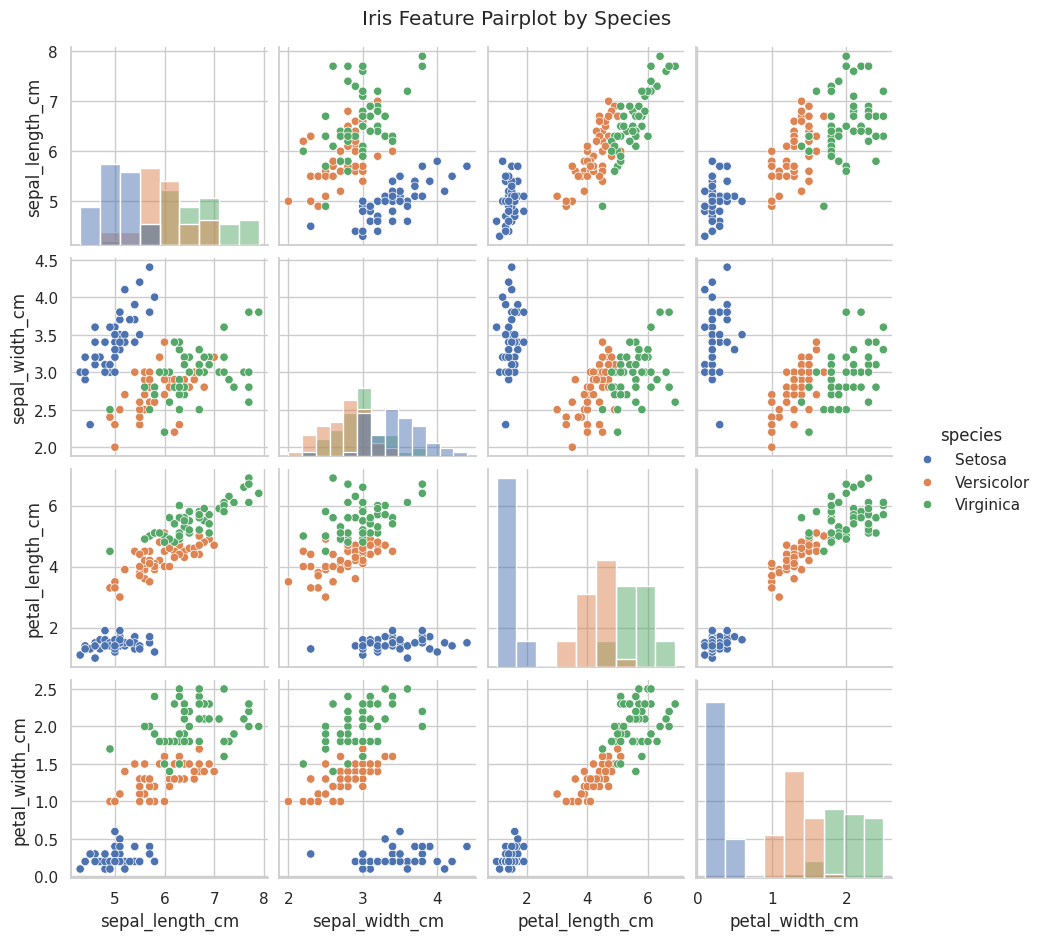

In [7]:
# Pairplot: required feature-distribution visualisation
pairplot = sns.pairplot(
    df,
    vars=feature_columns,
    hue='species',
    corner=False,
    diag_kind='hist',
    height=2.3,
)
pairplot.figure.suptitle('Iris Feature Pairplot by Species', y=1.02)
pairplot.savefig(OUTPUT_DIR / '01_pairplot.png', dpi=200, bbox_inches='tight')
plt.show()


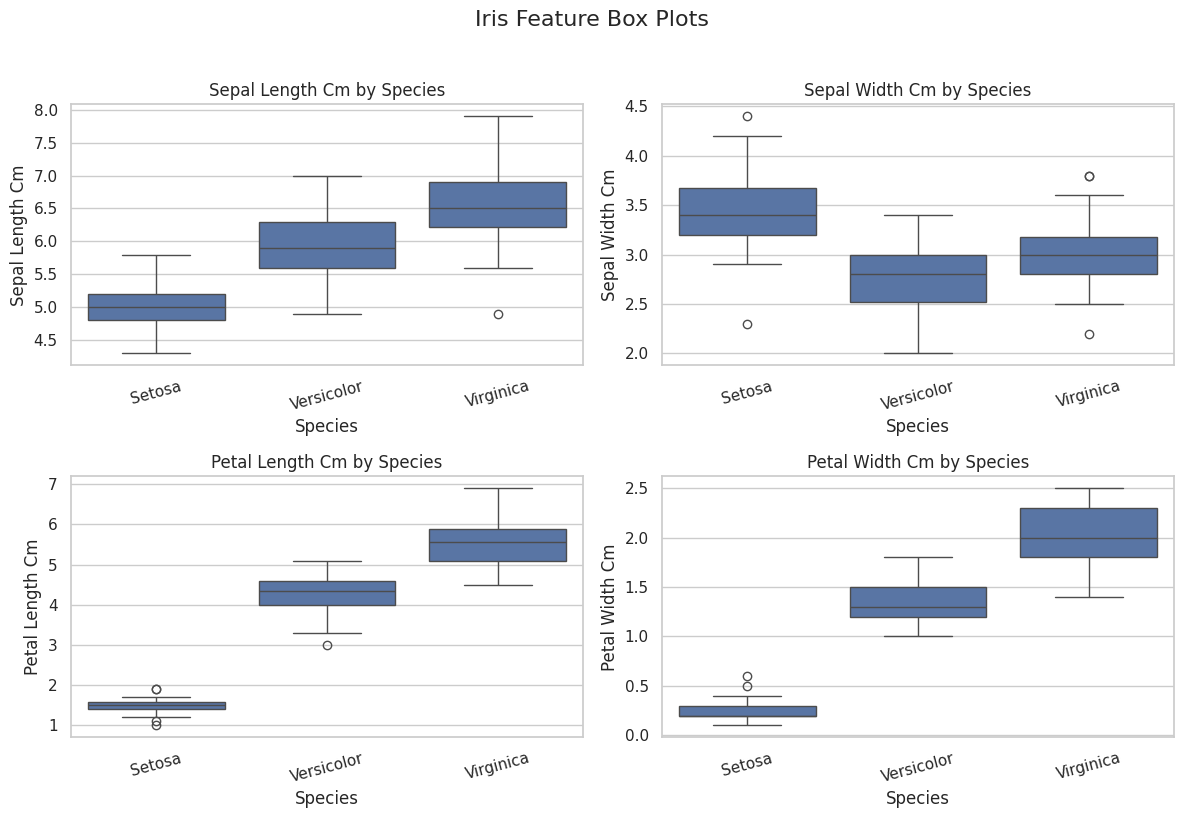

In [8]:
# Box plots for every feature: required visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, feature_columns):
    sns.boxplot(data=df, x='species', y=feature, ax=ax)
    ax.set_title(f'{feature.replace("_", " ").title()} by Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(feature.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Iris Feature Box Plots', fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '02_boxplots.png', dpi=200, bbox_inches='tight')
plt.show()


## 3. Feature Selection / Discriminative Feature Discussion

The pairplot and box plots provide a visual check, while class-wise means provide a numerical comparison. We will also use feature importance from the Random Forest later as a model-based signal.

A feature is considered more discriminative when its values show stronger separation between the three species. The conclusion below is based on the observed class-wise measurements and the trained model's feature-importance values, rather than on a visual guess alone.

In [9]:
# Class-wise feature means
class_means = df.groupby('species')[feature_columns].mean().T
class_means


species,Setosa,Versicolor,Virginica
sepal_length_cm,5.0060,5.9360,6.5880
sepal_width_cm,3.4280,2.7700,2.9740
petal_length_cm,1.4620,4.2600,5.5520
petal_width_cm,0.2460,1.3260,2.0260


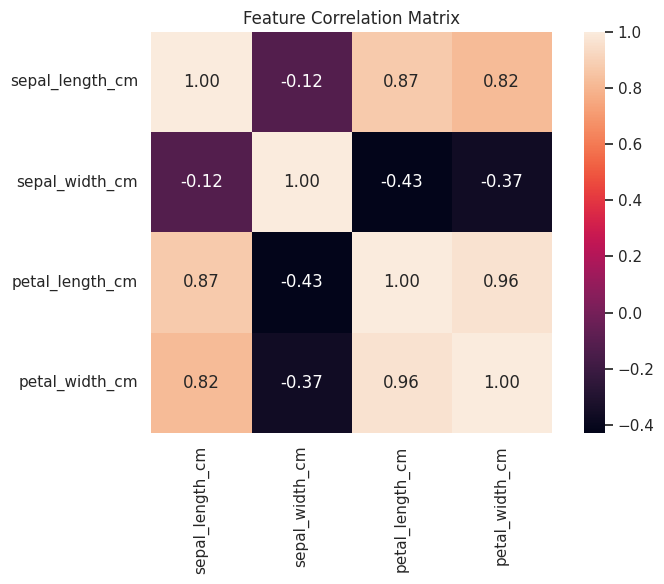

In [10]:
# Correlation matrix among numerical features
correlation_matrix = df[feature_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


### Initial feature-selection observation

From the class-wise distributions and pairwise plots, **petal length and petal width show strong separation among species**, while sepal measurements overlap more between some classes. We will validate this observation again with Random Forest feature importance after model training.

## 4. Train/Test Split — 80/20

The task requires a typical 80/20 train-test split. Stratification keeps the proportion of each iris species consistent between the training and test sets.

In [11]:
X = df[feature_columns]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))
print('Training percentage:', len(X_train) / len(df) * 100)
print('Testing percentage:', len(X_test) / len(df) * 100)


Training samples: 120
Testing samples: 30
Training percentage: 80.0
Testing percentage: 20.0


## 5. Train Two Classification Models

We will train two different classifiers, as required:

1. **Logistic Regression** with feature standardisation.
2. **Random Forest Classifier** using the original feature scales.

The same train/test split is used for both models so the comparison is fair.

In [12]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)

print('Both models trained successfully.')


Both models trained successfully.


## 6. Evaluate Each Model

For every classifier, the task requires accuracy, confusion matrix, and a classification report containing precision, recall, and F1-score. We also calculate macro averages for an easy comparison across the three equally important species.

In [13]:
evaluation_rows = []
reports = {}
confusion_matrices = {}
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        target_names=[name.title() for name in iris.target_names],
        output_dict=True,
        zero_division=0,
    )
    
    evaluation_rows.append({
        'Model': name,
        'Accuracy': accuracy,
        'Macro Precision': precision,
        'Macro Recall': recall,
        'Macro F1': f1,
    })
    reports[name] = report
    confusion_matrices[name] = cm

results_df = pd.DataFrame(evaluation_rows).sort_values(
    by=['Accuracy', 'Macro F1'],
    ascending=False,
).reset_index(drop=True)

results_df.round(4)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.9333,0.9333,0.9333,0.9333
1,Random Forest,0.9000,0.9024,0.9000,0.8997


In [14]:
# Save model-comparison results for documentation
results_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
results_df.round(4)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.9333,0.9333,0.9333,0.9333
1,Random Forest,0.9000,0.9024,0.9000,0.8997


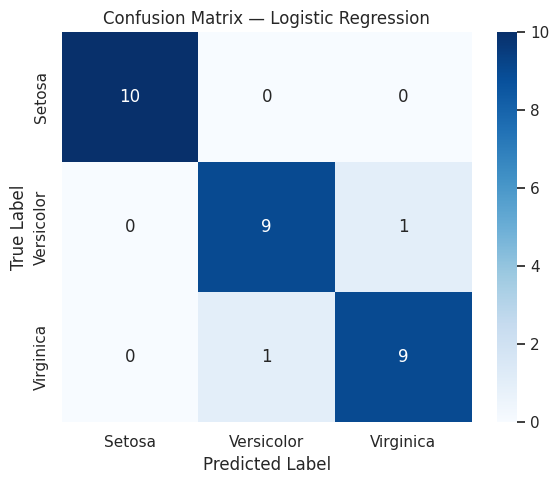

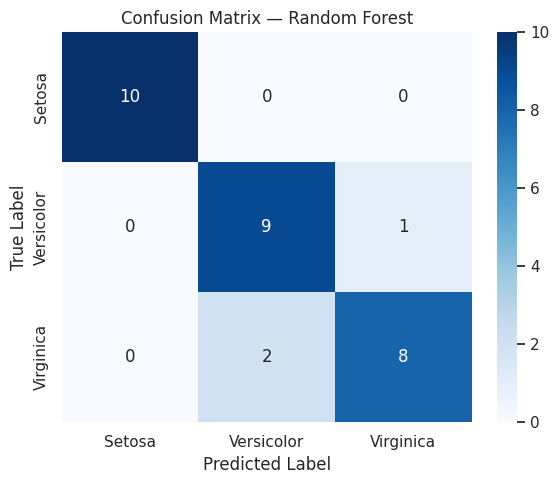

In [15]:
# Confusion matrix for each model
class_names = [name.title() for name in iris.target_names]

for name, cm in confusion_matrices.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    safe_name = name.lower().replace(' ', '_')
    plt.savefig(OUTPUT_DIR / f'confusion_matrix_{safe_name}.png', dpi=200, bbox_inches='tight')
    plt.show()


In [16]:
# Full classification reports for both models
for name, report in reports.items():
    report_df = pd.DataFrame(report).T
    print(f'\n=== {name} — Classification Report ===')
    display(report_df.round(4))
    safe_name = name.lower().replace(' ', '_')
    report_df.to_csv(OUTPUT_DIR / f'classification_report_{safe_name}.csv')



=== Logistic Regression — Classification Report ===


,precision,recall,f1-score,support
Setosa,1.0000,1.0000,1.0000,10.0000
Versicolor,0.9000,0.9000,0.9000,10.0000
Virginica,0.9000,0.9000,0.9000,10.0000
accuracy,0.9333,0.9333,0.9333,0.9333
macro avg,0.9333,0.9333,0.9333,30.0000
weighted avg,0.9333,0.9333,0.9333,30.0000



=== Random Forest — Classification Report ===


,precision,recall,f1-score,support
Setosa,1.0000,1.0000,1.0000,10.0000
Versicolor,0.8182,0.9000,0.8571,10.0000
Virginica,0.8889,0.8000,0.8421,10.0000
accuracy,0.9000,0.9000,0.9000,0.9000
macro avg,0.9024,0.9000,0.8997,30.0000
weighted avg,0.9024,0.9000,0.8997,30.0000


## 7. Select the Better-Performing Model

To keep the decision transparent and reproducible, we rank models by:

1. **Higher test accuracy**
2. **Higher macro F1-score** as the tie-breaker

This is a comparison rule for this project run — it is not a claim that one algorithm is universally better for every dataset.

In [17]:
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']
best_macro_f1 = results_df.iloc[0]['Macro F1']

print(f'Best-performing model for this test split: {best_model_name}')
print(f'Test accuracy: {best_accuracy:.4f} ({best_accuracy * 100:.2f}%)')
print(f'Macro F1-score: {best_macro_f1:.4f}')


Best-performing model for this test split: Logistic Regression
Test accuracy: 0.9333 (93.33%)
Macro F1-score: 0.9333


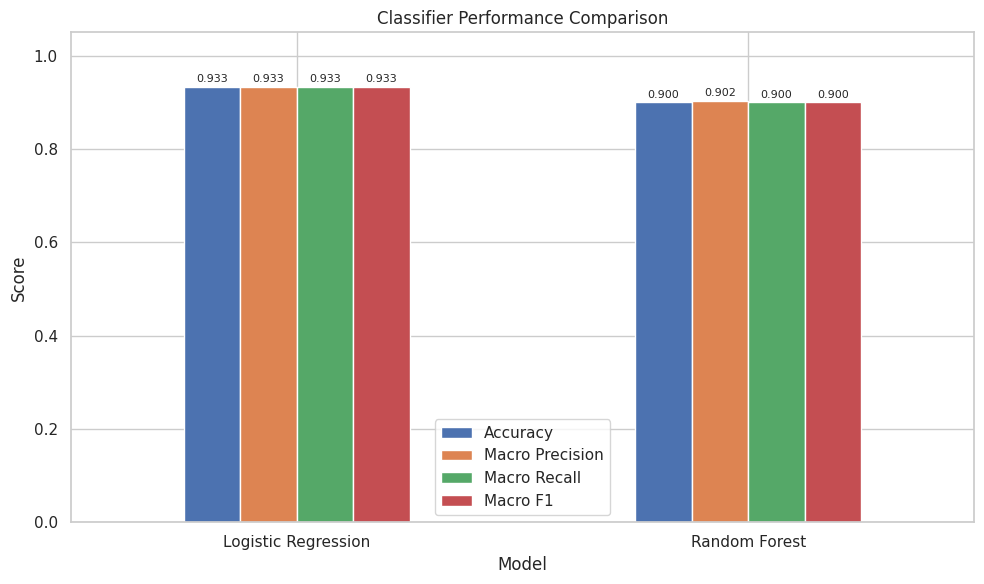

In [18]:
# Visual comparison of the two classifiers
comparison_plot = results_df.set_index('Model')[['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']]

ax = comparison_plot.plot(kind='bar', figsize=(10, 6))
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Classifier Performance Comparison')
ax.tick_params(axis='x', rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()


## 8. Model-Based Feature Importance

Random Forest provides a direct feature-importance estimate. This gives an additional, model-based way to support the earlier EDA observation about discriminative features.

In [19]:
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_,
}).sort_values('Importance', ascending=False)

importance_df.to_csv(OUTPUT_DIR / 'random_forest_feature_importance.csv', index=False)
importance_df


,Feature,Importance
2,petal_length_cm,0.4538
3,petal_width_cm,0.4124
0,sepal_length_cm,0.1159
1,sepal_width_cm,0.0179


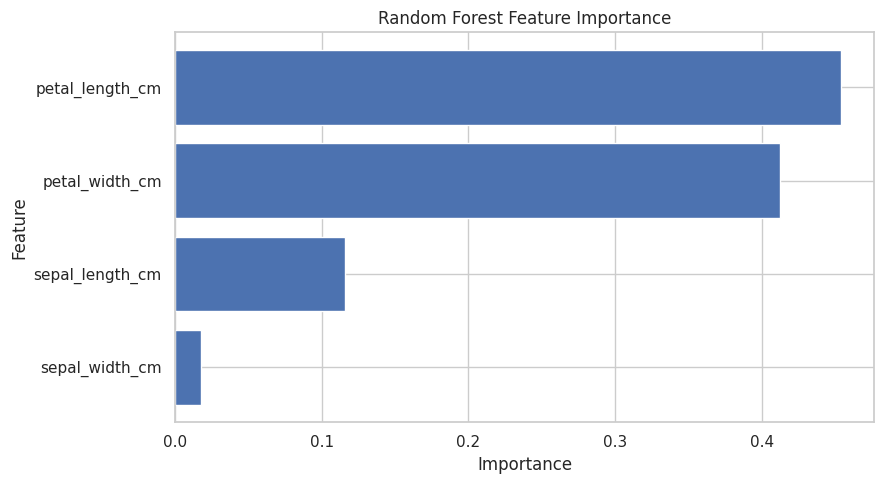

In [20]:
plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()


In [21]:
top_feature = importance_df.iloc[0]['Feature']
second_feature = importance_df.iloc[1]['Feature']
print(
    f"For this Random Forest run, the two most important features are "
    f"{top_feature.replace('_', ' ')} and {second_feature.replace('_', ' ')}."
)


For this Random Forest run, the two most important features are petal length cm and petal width cm.


## 9. Final Conclusion

### Findings

- The Iris dataset contains three flower species and four numerical measurement features.
- The required EDA shows that **petal measurements provide strong class separation**, especially compared with the greater overlap visible in some sepal measurements.
- Two classifiers were trained using the same 80/20 stratified split: Logistic Regression and Random Forest.
- Each model was evaluated with accuracy, confusion matrix, precision, recall, and F1-score.
- The model selected above is the better performer **for this specific test split**, using higher accuracy and macro F1 as the comparison criteria.
- Random Forest feature importance gives an additional quantitative check of which measurements contributed most to classification.

### Oasis Infobyte Task 1 checklist

| Requirement | Completed in notebook |
|---|---|
| Built-in `load_iris()` dataset | ✅ |
| Shape inspection | ✅ |
| Data types inspection | ✅ |
| Null-value check | ✅ |
| Descriptive statistics | ✅ |
| Pairplot / scatter matrix | ✅ Pairplot |
| Box plots for every feature | ✅ |
| Feature-selection discussion | ✅ |
| 80/20 train-test split | ✅ |
| At least two classifiers | ✅ 2 models |
| Accuracy | ✅ |
| Confusion matrix | ✅ for both models |
| Precision, recall, F1 | ✅ for both models |
| Best model + justification | ✅ |
| Clean, commented Jupyter Notebook | ✅ |

> **Important:** The numerical results in this notebook are generated by executing the notebook with `random_state=42`. Run all cells before submission so your GitHub notebook shows the actual results and plots.

## 10. Reproducibility

```bash
pip install -r requirements.txt
jupyter notebook
```

Open `Iris_Flower_Classification.ipynb` and run all cells from top to bottom.